# BraTS with 3D MRIs

Initial implementation assumptions:

- mask will be binary, disregarding GD-enhancing tumor (ET), the peritumoral edema (ED), and necrotic and non-enhancing tumor core (NCR/NET).
- MRI slices will be treated as 'stand-alone'.

In [3]:
import os

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
import torch
import torch.optim as optim

from PIL import Image
import nibabel as nib
import numpy as np
from sklearn.metrics import confusion_matrix
import random
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Data
training_data_path = "../data/raw/training"
validation_data_path = "../data/raw/validation"
preprocessed_data_path = "../data/preprocessed"
slices_per_mri = 155 # For all MRIs the total slices is the same

T1CE_SUFFIX = "_t1ce.nii"
T2_SUFFIX = "_t2.nii"
FLAIR_SUFFIX = "_flair.nii"
SEG_SUFFIX = "_seg.nii"

RAND_SEED = 18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("NVIDIA Cuda available: ", torch.cuda.is_available())
print("GPU: ", torch.cuda.get_device_name(0))

NVIDIA Cuda available:  True
GPU:  NVIDIA GeForce GTX 1050 Ti


## Utils

In [18]:
# @title Utils

def get_patient_dirs(data_path):
    patient_dirs = []
    for patient_folder in os.listdir(data_path):
        patient_path = os.path.join(data_path, patient_folder)
        if os.path.isdir(patient_path):
            patient_dirs.append(patient_path)
    return patient_dirs

def normalize_channel(img):
    img_min = img.min()
    img_max = img.max()
    if img_max - img_min == 0:
        return torch.zeros_like(img)
    return (img - img_min) / (img_max - img_min)

def visualize_random_batch_from_dataset(dataset, n=6, rand_seed=None, show_mask=True, vis_start_idx=None):
    if rand_seed is not None:
        random.seed(rand_seed)
        torch.manual_seed(rand_seed)
    
    start_idx = random.randint(0, len(dataset)//2) if not vis_start_idx else vis_start_idx
    indices = [start_idx+(i*100) for i in range(n)]
    cols = 3
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 5, rows * 5))

    for i, idx in enumerate(indices):
        img, mask = dataset[idx]  # img: (3, H, W), mask: (H, W)

        t1ce_norm = normalize_channel(img[0])
        t2_norm = normalize_channel(img[1])
        flair_norm = normalize_channel(img[2])

        rgb_img = torch.stack([t1ce_norm, t2_norm, flair_norm], dim=0)  # (3, H, W)
        rgb_img_np = rgb_img.permute(1, 2, 0).numpy()  # (H, W, 3)
        mask_np = mask.numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(rgb_img_np, origin='lower')
        if show_mask:
            plt.imshow(mask_np, cmap='gray', alpha=0.4, origin='lower')
        plt.axis("off")
        plt.title(f"Sample {idx}")

    plt.tight_layout()
    plt.show()

def visualize_random_batch_from_raw(data_path, n=3, slice_index=50, rand_seed=None):
    if rand_seed is not None:
        random.seed(rand_seed)

    patient_dirs = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    selected_patients = random.sample(patient_dirs, n)

    fig, axes = plt.subplots(n, 3, figsize=(18, 6 * n))

    if n == 1:
        axes = [axes]

    for i, patient_id in enumerate(selected_patients):
        path = os.path.join(data_path, patient_id, patient_id)

        t1ce = nib.load(path + T1CE_SUFFIX).get_fdata()
        t2 = nib.load(path + T2_SUFFIX).get_fdata()
        flair = nib.load(path + FLAIR_SUFFIX).get_fdata()
        seg = nib.load(path + SEG_SUFFIX).get_fdata()

        t1ce_slice = t1ce[:, :, slice_index]
        t2_slice = t2[:, :, slice_index]
        flair_slice = flair[:, :, slice_index]
        seg_slice = seg[:, :, slice_index]

        t1ce_norm = normalize_channel(t1ce_slice)
        t2_norm = normalize_channel(t2_slice)
        flair_norm = normalize_channel(flair_slice)

        rgb_img = torch.from_numpy(np.stack([t1ce_norm, t2_norm, flair_norm], axis=-1)).float()
        seg_mask = (torch.from_numpy(seg_slice) > 0).float()

        ax1, ax2, ax3 = axes[i]

        ax1.imshow(rgb_img.permute(1, 0, 2).numpy(), origin='lower')
        ax1.set_title(f'{patient_id}: RGB Composite')
        ax1.axis('off')

        ax2.imshow(seg_mask.T.numpy(), cmap='gray', origin='lower')
        ax2.set_title(f'{patient_id}: Segmentation Mask (Slice {slice_index})')
        ax2.axis('off')

        ax3.imshow(rgb_img.permute(1, 0, 2).numpy(), origin='lower')
        ax3.imshow(seg_mask.T.numpy(), cmap='gray', alpha=0.4, origin='lower')
        ax3.set_title(f'{patient_id}: Overlay')
        ax3.axis('off')

    plt.tight_layout()
    plt.show()

def timer(func):
    def wrapper(*args, **kwargs):
        start = datetime.datetime.now()
        result = func(*args, **kwargs)
        end = datetime.datetime.now()
        print(f"[{func.__name__}] Time elapsed: {end-start}")
        return result
    return wrapper

## Preprocessing

In [15]:
image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

def preprocess_brats_to_pt(data_path, output_path):
    os.makedirs(output_path, exist_ok=True)
    patient_dirs = get_patient_dirs(data_path)

    for patient_dir in tqdm(patient_dirs, desc="Preprocessing"):
        basename = os.path.basename(patient_dir)

        t1ce  = nib.load(os.path.join(patient_dir, basename + T1CE_SUFFIX)).get_fdata()
        t2    = nib.load(os.path.join(patient_dir, basename + T2_SUFFIX)).get_fdata()
        flair = nib.load(os.path.join(patient_dir, basename + FLAIR_SUFFIX)).get_fdata()
        seg   = nib.load(os.path.join(patient_dir, basename + SEG_SUFFIX)).get_fdata()

        if not (t1ce.shape == t2.shape == flair.shape == seg.shape):
            print(f"Skipping inconsistent patient: {basename}")
            continue

        padded_images = []
        padded_masks = []

        depth = t1ce.shape[-1]
        for i in range(depth):
            img_stack = np.stack([
                t1ce[:, :, i],
                t2[:, :, i],
                flair[:, :, i]
            ], axis=-1)  # shape: (H, W, 3)

            # Convert to PIL image for transforms
            img_pil = Image.fromarray(((img_stack - np.min(img_stack)) / (np.ptp(img_stack) + 1e-8) * 255).astype(np.uint8))
            img_transformed = image_transform(img_pil)  # shape: (3, 256, 256)

            # Prepare mask
            mask_slice = (seg[:, :, i] > 0).astype(np.uint8) * 255
            mask_pil = Image.fromarray(mask_slice)
            mask_transformed = mask_transform(mask_pil).squeeze(0)  # shape: (256, 256)

            padded_images.append(img_transformed)
            padded_masks.append(mask_transformed)

        image_tensor = torch.stack(padded_images, dim=-1)  # (3, 256, 256, D)
        mask_tensor  = torch.stack(padded_masks, dim=-1)   # (256, 256, D)

        torch.save({
            'image': image_tensor,
            'mask': mask_tensor
        }, os.path.join(output_path, f"{basename}.pt"))

preprocess_brats_to_pt(training_data_path, preprocessed_data_path)

Preprocessing: 100%|█████████████████████████████████████████████████████████████████| 369/369 [10:34<00:00,  1.72s/it]


## Dataset creation and loader

In [24]:
class LazyBraTSTiffDataset(Dataset):
    def __init__(self, data_path, slices_size, lazy_chunk_size=30):
        self.data_path = data_path
        self.files = [f for f in os.listdir(data_path) if f.endswith('.pt')]
        random.shuffle(self.files)
        self.data_size = len(self.files)
        self.slices_size = slices_size
        self.total_image_size = self.data_size*self.slices_size
        
        self.data = {}
        self.chunk_size = lazy_chunk_size
        self.chunk_start = 0
        self.chunk_end = lazy_chunk_size

        self._load_chunk()

    def __len__(self):
        return self.total_image_size

    def __iter__(self):
        for idx in range(self.total_image_size):
            yield self[idx]
    
    def __getitem__(self, idx):
        if idx not in self.data:
            if idx >= self.total_image_size:
                raise ValueError(f"index {idx} not valid for length {self.total_image_size}")
            self._move_chunk(idx)
            self._load_chunk()
        return self.data[idx]

    def _move_chunk(self, idx):
        mri_from_slice = idx // self.slices_size
        self.chunk_start = mri_from_slice
        self.chunk_end = min(mri_from_slice + self.chunk_size, self.data_size)

    def _load_chunk(self):
        self.data.clear()
        for patient_idx in range(self.chunk_start, self.chunk_end):
            data = torch.load(os.path.join(self.data_path, self.files[patient_idx]), map_location='cpu', weights_only=False)

            start_slice_idx = patient_idx * self.slices_size
            for i in range(self.slices_size):
                image = data['image'][:, :, :, i]
                mask = data['mask'][:, :, i]
                self.data[start_slice_idx + i] = (image, mask)

In [25]:
dataset = LazyBraTSTiffDataset("../data/preprocessed/brats_nii/", 155)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False) # Shuffling is done in dataset

In [46]:
a = 0
for batch in tqdm(dataloader, "dataloader"):
    a += 1
print(a)

dataloader: 100%|█████████████████████████████████████████████████████████████████| 7150/7150 [01:03<00:00, 112.99it/s]

7150


## Visualizations

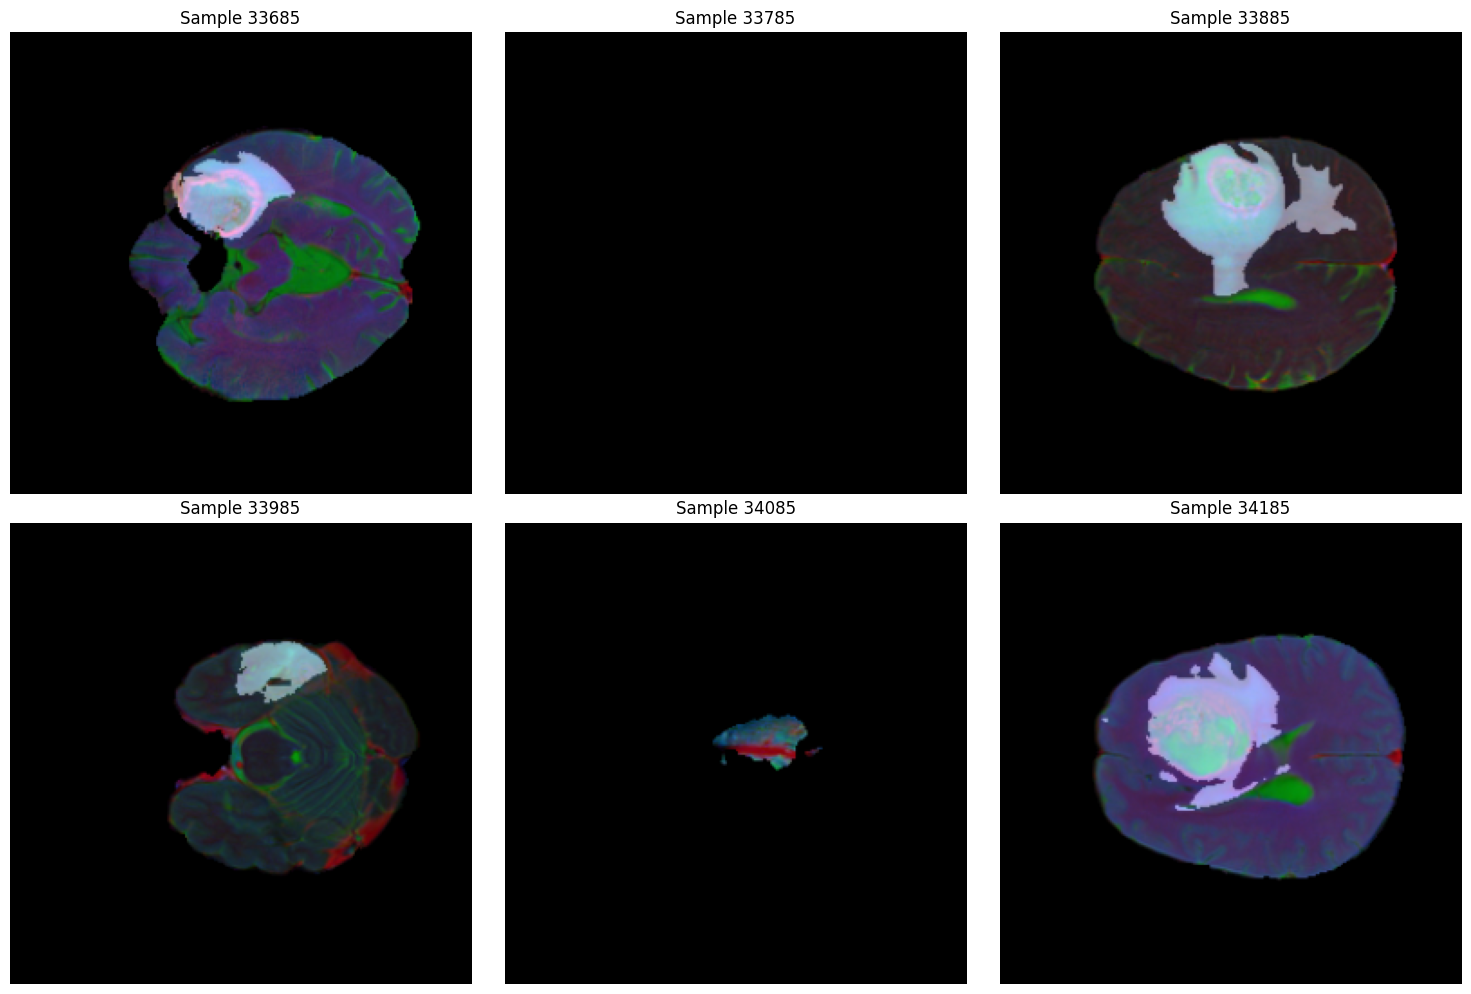

In [27]:
# From dataset
visualize_random_batch_from_dataset(dataset, n=6, rand_seed=RAND_SEED, show_mask=True, vis_start_idx=33685)

preproc vs raw

torch.Size([3, 256, 256]) torch.Size([256, 256])


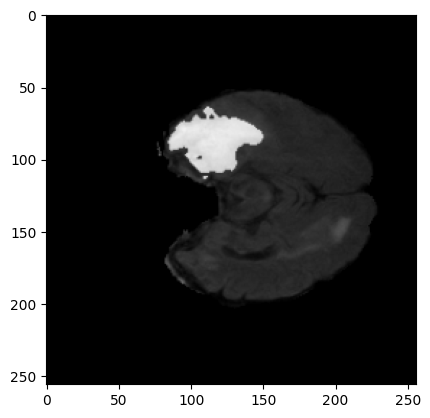

In [125]:
# preproc
img, mask = dataset[50]
print(img.shape, mask.shape)
mask_np = mask.numpy()

plt.imshow(img[2], cmap="gray")
# plt.imshow(mask_np, cmap="gray", alpha=0.6)
plt.show()

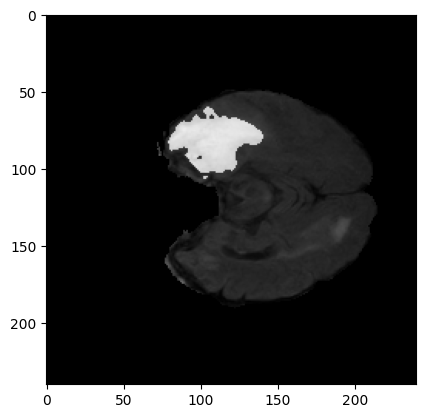

In [124]:
# raw
slice_index = 50
patient_id = "BraTS20_Training_328"
path = os.path.join("../data/raw/brats_nii/training", patient_id, patient_id)

t1ce = nib.load(path + T1CE_SUFFIX).get_fdata()
t2 = nib.load(path + T2_SUFFIX).get_fdata()
flair = nib.load(path + FLAIR_SUFFIX).get_fdata()
seg = nib.load(path + SEG_SUFFIX).get_fdata()

t1ce_slice = t1ce[:, :, slice_index]
t2_slice = t2[:, :, slice_index]
flair_slice = flair[:, :, slice_index]
seg_slice = seg[:, :, slice_index]

t1ce_norm = normalize_channel(t1ce_slice)
t2_norm = normalize_channel(t2_slice)
flair_norm = normalize_channel(flair_slice)

seg_mask = (torch.from_numpy(seg_slice) > 0).float()

plt.imshow(flair_slice, cmap="gray")
# plt.imshow(seg_mask, cmap="gray", alpha=0.6)
plt.show()

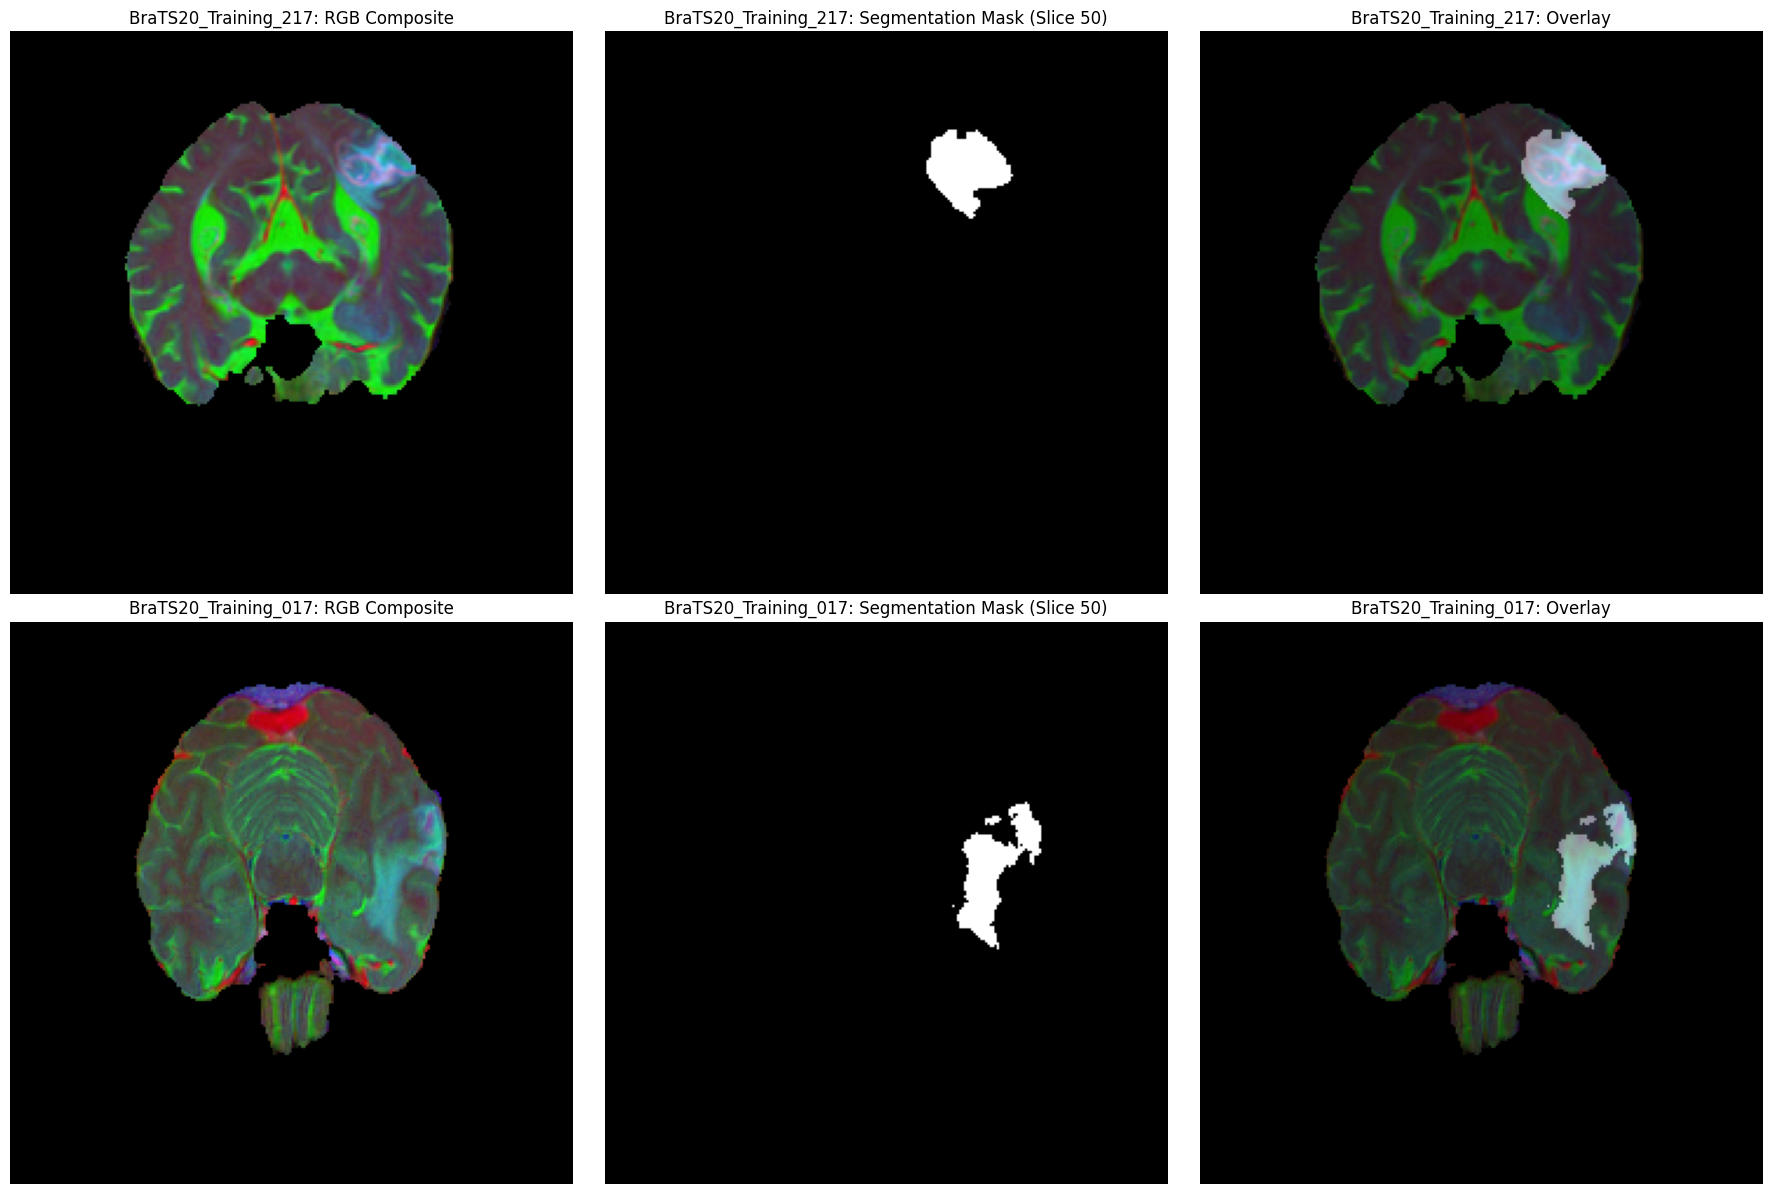

In [89]:
# Raw
visualize_random_batch_from_raw("../data/raw/brats_nii/training", n=2)

## Model training

In [127]:
# MobileNetV2 U-Net Model
class MobileNetV2UNet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        base = models.mobilenet_v2(weights=None).features
        self.enc0 = base[0:2]   # Output: 16
        self.enc1 = base[2:4]   # Output: 24
        self.enc2 = base[4:7]   # Output: 32
        self.enc3 = base[7:14]  # Output: 96
        self.enc4 = base[14:]   # Output: 1280

        self.up1 = self._upsample_block(1280, 96)
        self.up2 = self._upsample_block(96 + 96, 64)
        self.up3 = self._upsample_block(64 + 32, 32)
        self.up4 = self._upsample_block(32 + 24, 24)
        self.up5 = self._upsample_block(24 + 16, 16)

        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def _upsample_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_ch)
        )

    def forward(self, x):
        # Encoder side
        e0 = self.enc0(x)  # 16
        e1 = self.enc1(e0) # 24
        e2 = self.enc2(e1) # 32
        e3 = self.enc3(e2) # 96
        e4 = self.enc4(e3) # 1280

        # Decoder side and skip connections
        d1 = self.up1(e4)                    # → 96
        d2 = self.up2(torch.cat([d1, e3], dim=1))  # → 64
        d3 = self.up3(torch.cat([d2, e2], dim=1))  # → 32
        d4 = self.up4(torch.cat([d3, e1], dim=1))  # → 24
        d5 = self.up5(torch.cat([d4, e0], dim=1))  # → 16

        out = self.final(d5)                # → 1
        return torch.sigmoid(out)

# Metrics
def dice_score(pred, target, epsilon=1e-6):
    pred = (pred > 0.5).float()
    target = target.float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2. * intersection + epsilon) / (union + epsilon)
    return dice.mean()

# Training Loop
def train_model(model, loader, criterion, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss, epoch_dice = 0, 0
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks.unsqueeze(1))
            dice = dice_score(outputs, masks.unsqueeze(1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_dice += dice.item()

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss/len(loader):.4f} | Dice: {epoch_dice/len(loader):.4f}")

# Hyperparams & Run
dataset = LazyBraTSTiffDataset("../data/preprocessed/brats_nii/", 155)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False) # Shuffling is done in dataset

model = MobileNetV2UNet().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_model(model, dataloader, criterion, optimizer, num_epochs=10)

# Save model
torch.save(model.state_dict(), "../models/brats_nii_mobilenetv2_unet.pth")

# model = MobileNetV2UNet().to(device)
# model.load_state_dict(torch.load("../models/brats_tif_mobilenetv2_unet.pth", weights_only=True))

Epoch 1/10 - Loss: 0.1499 | Dice: 0.5651
Epoch 2/10 - Loss: 0.0103 | Dice: 0.7870
Epoch 3/10 - Loss: 0.0078 | Dice: 0.8156
Epoch 4/10 - Loss: 0.0069 | Dice: 0.8295
Epoch 5/10 - Loss: 0.0063 | Dice: 0.8450
Epoch 6/10 - Loss: 0.0058 | Dice: 0.8552
Epoch 7/10 - Loss: 0.0054 | Dice: 0.8629
Epoch 8/10 - Loss: 0.0050 | Dice: 0.8712
Epoch 9/10 - Loss: 0.0047 | Dice: 0.8798
Epoch 10/10 - Loss: 0.0045 | Dice: 0.8817


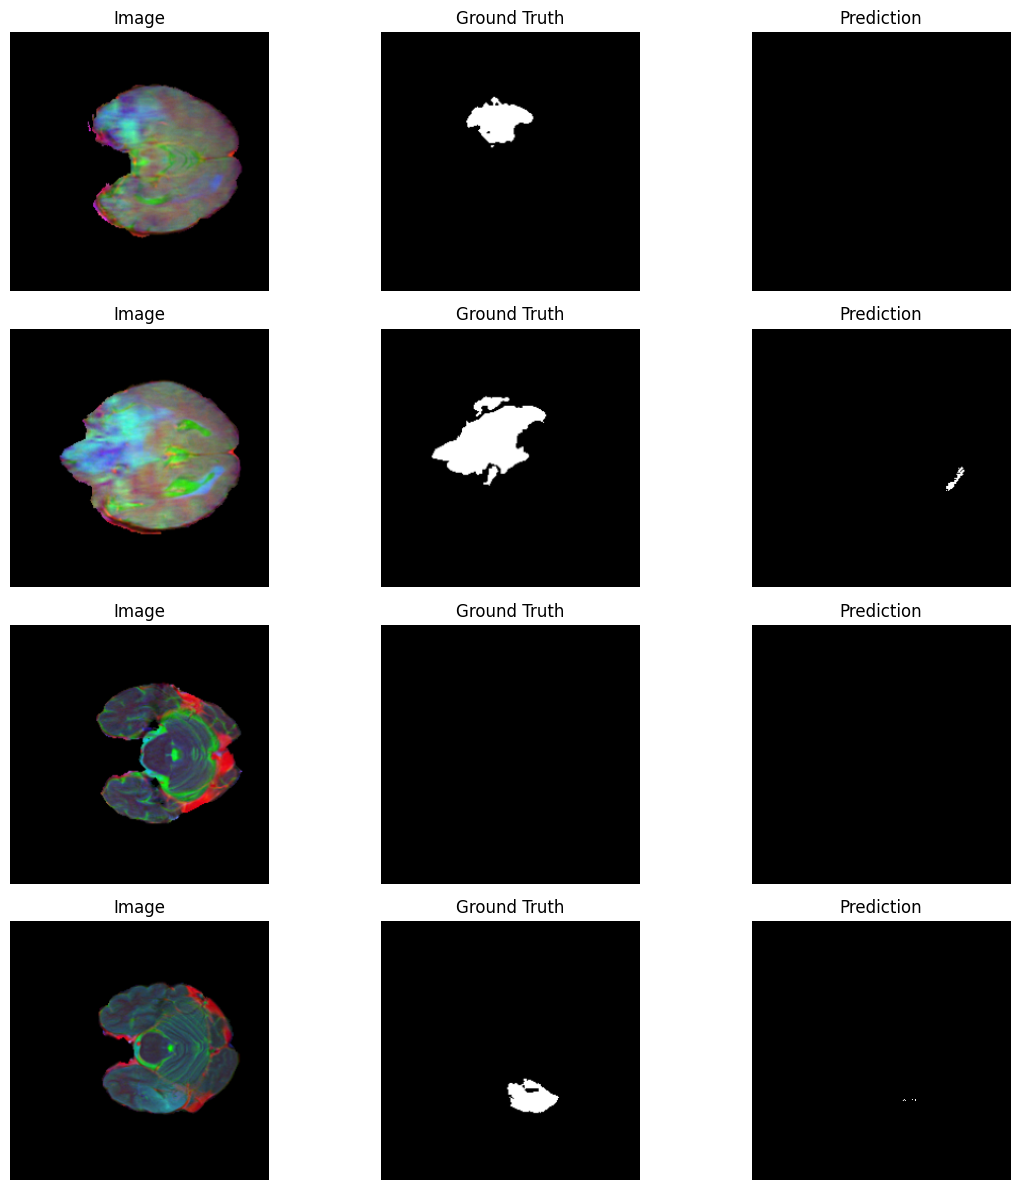

In [131]:
def normalize_channel(img):
    img_min = img.min()
    img_max = img.max()
    if img_max - img_min == 0:
        return torch.zeros_like(img)
    return (img - img_min) / (img_max - img_min)

def visualize_predictions(model, dataset, n=4):
    model.eval()
    indices = [50, 60, 350, 33985]
    plt.figure(figsize=(12, n * 3))

    for i, idx in enumerate(indices):
        img, mask = dataset[idx]

        t1ce_norm = normalize_channel(img[0])
        t2_norm = normalize_channel(img[1])
        flair_norm = normalize_channel(img[2])

        rgb_img = torch.stack([t1ce_norm, t2_norm, flair_norm], dim=0)  # (3, H, W)
        rgb_img_np = rgb_img.permute(1, 2, 0).numpy()  # (H, W, 3)

        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device))  # add batch dim: (1, C, H, W)
            pred = pred.cpu().squeeze().numpy()  # remove batch dim and channel dim

        mask_np = mask.squeeze().numpy()
        pred_np = (pred > 0.5).astype(float)

        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(rgb_img_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(mask_np, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(pred_np, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(model, dataset)